# CodeAlpha Machine Learning Internship

## Task 4: Heart Disease Prediction using Machine Learning

### Submitted By

**Kondam Supriya**

### Objective

The objective of this project is to predict the likelihood of heart disease using patient medical data and machine learning classification algorithms. The project focuses on data preprocessing, model training, prediction, and performance evaluation to identify whether a patient is at risk of heart disease.

### Dataset

- **Dataset Name:** UCI Heart Disease Dataset
- **Total Records:** 920
- **Total Features:** 16
- **Target Column:** num

### Tools Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Step 1: Import Required Libraries

Import all the necessary Python libraries required for data manipulation, visualization, preprocessing, machine learning model development, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 2: Load the Dataset

Load the Heart Disease dataset into Google Colab and display the first few records to understand the structure of the dataset.

In [2]:
df = pd.read_csv("heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Step 3: Explore the Dataset

Analyze the dataset by checking its dimensions, column names, data types, and summary statistics.

In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## Step 4: Check Missing Values

Identify missing values in the dataset before performing data preprocessing.

In [4]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


## Step 5: Data Preprocessing

Handle missing values, encode categorical variables, and prepare the dataset for machine learning model training.

In [5]:
# Remove unnecessary ID column
df = df.drop("id", axis=1)

# Convert target column into binary classification
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

# Fill missing numerical values
num_imputer = SimpleImputer(strategy="median")
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Fill missing categorical values
cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Encode categorical columns
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63.0,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0.0
1,67.0,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1.0
2,67.0,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1.0
3,37.0,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0.0
4,41.0,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0.0


## Step 6: Split the Dataset

Split the dataset into training and testing sets to evaluate the performance of the machine learning models.

In [6]:
X = df.drop("num", axis=1)

y = df["num"]

print(X.shape)

print(y.shape)

(920, 14)
(920,)


## Step 7: Train Logistic Regression Model

Train the Logistic Regression classifier using the training dataset and evaluate its prediction performance.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Step 8: Train Support Vector Machine (SVM)

Train the Support Vector Machine model and compare its prediction accuracy with other models.

In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8260869565217391


## Step 9: Train Random Forest Model

Build and train the Random Forest classifier to improve prediction performance.

In [9]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7445652173913043


## Step 10: Compare Model Performance

Compare the performance of all trained models using accuracy scores and visualization.

In [10]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8532608695652174


## Step 11: Compare Model Performance

Compare the accuracy of all machine learning models using a table and a bar chart.

In [11]:
accuracy_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Support Vector Machine", "Random Forest"],
    "Accuracy": [lr_acc, svm_acc, rf_acc]
})

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.826087
1,Support Vector Machine,0.744565
2,Random Forest,0.853261


## Step 12: Visualize Model Accuracy

Display a bar chart to compare the performance of the trained machine learning models.

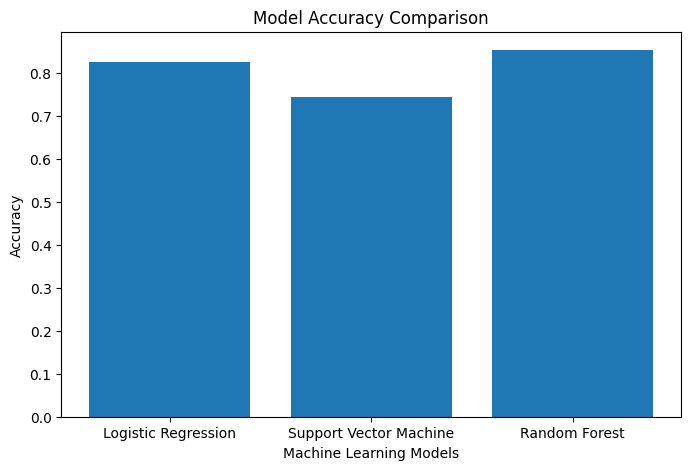

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.show()

## Step 13: Confusion Matrix and Classification Report

Evaluate the best-performing model using a confusion matrix and a classification report.

In [13]:
print(confusion_matrix(y_test, rf_pred))

print()

print(classification_report(y_test, rf_pred))

[[68 14]
 [13 89]]

              precision    recall  f1-score   support

         0.0       0.84      0.83      0.83        82
         1.0       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## Step 14: Predict Heart Disease

Predict whether a sample patient is likely to have heart disease using the trained Random Forest model.

In [14]:
sample_patient = X_test.iloc[[0]]

prediction = rf.predict(sample_patient)

if prediction[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


## Step 15: Conclusion

This project successfully implemented multiple machine learning algorithms to predict heart disease using the UCI Heart Disease dataset. After preprocessing the data and training different models, their performance was compared. The Random Forest model achieved strong prediction performance and proved effective for heart disease classification. This project demonstrates how machine learning can support healthcare by assisting in disease prediction.

## Step 16: Acknowledgement

This project was completed as part of the CodeAlpha Machine Learning Internship. It provided practical experience in data preprocessing, machine learning model development, model evaluation, and predictive analytics using Python and Scikit-learn.